In [ ]:
from dataclasses import dataclass


@dataclass
class GroupInfo:
    k: int
    row_num: int
    start_x: int
    roots: list[tuple[int, int]]

    now_pos: int
    size: int

class ManageGroupInfo:

    def __init__(self, k: int, n: int, init_pos: int = 2):
        self.n = n
        self.k = k
        self.init_pos = init_pos

        self.infos: list[GroupInfo] = self._construct_group_info()

    def _create_root(self, x: int, row_num: int) -> list[tuple[int, int]]:
        roots: list[tuple[int, int]] = [(self.n-1, x)]
        for r in range(row_num):
            if r % 2 == 0:
                for i in range(self.n-2, -1, -1):
                    roots.append((i, x+r))
            else:
                for i in range(self.n-1):
                    roots.append((i, x+r))
        return roots[::-1]

    def _construct_group_info(self) -> None:
        num_list: list[int] = [1] * self.k
        for i in range(self.n-self.k):
            num_list[0] += 1
            num_list = sorted(num_list)

        acc_num_list: list[int] = [0] * (self.k)
        for i in range(self.k-1):
            acc_num_list[i+1] += num_list[i] + acc_num_list[i]

        infos: list[GroupInfo] = []
        for ki in range(self.k):
            row_num: int = num_list[ki]
            start_x: int = acc_num_list[ki]
            roots: list[tuple[int, int]] = self._create_root(start_x, row_num)
            info = GroupInfo(ki, row_num, start_x, roots, self.init_pos, len(roots)-1)
            infos.append(info)

        return infos

    def get_start_x(self, k: int) -> int:
        return self.infos[k].start_x

    def get_now_pos(self, k: int) -> int:
        return self.infos[k].now_pos

    def get_partition_pos(self, k: int, num) -> tuple[int, int, int, int]:
        assert 0 < num <= self.infos[k].size
        y1, x1 = self.infos[k].roots[num-1]
        y2, x2 = self.infos[k].roots[num]
        return (y1, x1, y2, x2)

    def change_now_pos(self, k: int, pos: int) -> None:
        self.infos[k].now_pos = pos

In [28]:
K = 9
N = 20
manage_group_info = ManageGroupInfo(k=K, n=N, init_pos=2)

In [29]:
grid = [[-1 for _ in range(N)] for _ in range(N)]

In [30]:
for k in range(K):
    for i in range(len(manage_group_info.infos[k].roots)):
        y, start_x = manage_group_info.infos[k].roots[i]
        grid[y][start_x] = k * 1000 + i

In [37]:
manage_group_info.get_partition_pos(0, 38)

(18, 0, 19, 0)

19 18 1019 1018 2019 2018 3019 3018 4019 4018 5019 5018 6019 6018 7038 7037 7000 8038 8037 8000
20 17 1020 1017 2020 2017 3020 3017 4020 4017 5020 5017 6020 6017 7039 7036 7001 8039 8036 8001
21 16 1021 1016 2021 2016 3021 3016 4021 4016 5021 5016 6021 6016 7040 7035 7002 8040 8035 8002
22 15 1022 1015 2022 2015 3022 3015 4022 4015 5022 5015 6022 6015 7041 7034 7003 8041 8034 8003
23 14 1023 1014 2023 2014 3023 3014 4023 4014 5023 5014 6023 6014 7042 7033 7004 8042 8033 8004
24 13 1024 1013 2024 2013 3024 3013 4024 4013 5024 5013 6024 6013 7043 7032 7005 8043 8032 8005
25 12 1025 1012 2025 2012 3025 3012 4025 4012 5025 5012 6025 6012 7044 7031 7006 8044 8031 8006
26 11 1026 1011 2026 2011 3026 3011 4026 4011 5026 5011 6026 6011 7045 7030 7007 8045 8030 8007
27 10 1027 1010 2027 2010 3027 3010 4027 4010 5027 5010 6027 6010 7046 7029 7008 8046 8029 8008
28  9 1028 1009 2028 2009 3028 3009 4028 4009 5028 5009 6028 6009 7047 7028 7009 8047 8028 8009
29  8 1029 1008 2029 2008 3029 3008 4029

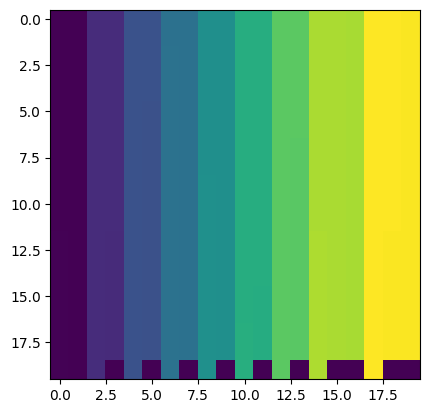

In [32]:
import matplotlib.pyplot as plt


def debug(grid):
    for i in range(N):
        print(" ".join(f"{grid[i][j]:2d}" for j in range(N)))
        
    plt.imshow(grid)
    plt.show()

debug(grid)